# ADL Lab 3.7


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


---
# Task 3.7.1 — Attention Mechanism Comparison
## Comparing With and Without Attention

In [2]:
# a simple French-English translation dataset
french_sentences = [
    "je suis heureux",
    "tu es triste",
    "il aime les chats",
    "elle parle francais",
    "nous jouons au football",
    "vous mangez du pain",
    "ils regardent la television",
    "elles chantent une chanson",
]

english_sentences = [
    "i am happy",
    "you are sad",
    "he loves cats",
    "she speaks french",
    "we play football",
    "you eat bread",
    "they watch television",
    "they sing a song",
]

def build_vocab(sentences):
    vocab = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
    idx = 4
    for sentence in sentences:
        for word in sentence.split():
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    return vocab

fr_vocab = build_vocab(french_sentences)
en_vocab = build_vocab(english_sentences)

print(f"French vocabulary size: {len(fr_vocab)}")
print(f"English vocabulary size: {len(en_vocab)}")

# reverse vocabulary
fr_idx2word = {idx: word for word, idx in fr_vocab.items()}
en_idx2word = {idx: word for word, idx in en_vocab.items()}

def sentence_to_indices(sentence, vocab, max_len=20):
    indices = [vocab['<SOS>']]
    for word in sentence.split():
        indices.append(vocab.get(word, vocab['<UNK>']))
    indices.append(vocab['<EOS>'])
    # Pad
    while len(indices) < max_len:
        indices.append(vocab['<PAD>'])
    return torch.tensor(indices[:max_len], dtype=torch.long)

class TranslationDataset(Dataset):
    def __init__(self, src_sentences, tgt_sentences, src_vocab, tgt_vocab):
        self.src = [sentence_to_indices(s, src_vocab) for s in src_sentences]
        self.tgt = [sentence_to_indices(s, tgt_vocab) for s in tgt_sentences]

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]

dataset = TranslationDataset(french_sentences, english_sentences, fr_vocab, en_vocab)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

print(f"Dataset size: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}"	)

French vocabulary size: 33
English vocabulary size: 27
Dataset size: 8
Number of batches: 4


## Encoder-Decoder WITHOUT Attention

In [3]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        # x: [batch, seq_len]
        embedded = self.embedding(x)  # [batch, seq_len, emb_dim]
        _, (h, c) = self.lstm(embedded)  # h,c: [1, batch, hidden_dim]
        return h, c

class DecoderNoAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h, c):
        # x: [batch, 1]
        embedded = self.embedding(x)  # [batch, 1, emb_dim]
        out, (h, c) = self.lstm(embedded, (h, c))  # [batch, 1, hidden_dim]
        logits = self.fc(out.squeeze(1))  # [batch, vocab_size]
        return logits, h, c

class Seq2SeqNoAttention(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, embedding_dim, hidden_dim)
        self.decoder = DecoderNoAttention(tgt_vocab_size, embedding_dim, hidden_dim)

    def forward(self, src, tgt, teacher_forcing_ratio=1.0):
        batch_size, seq_len = tgt.shape
        outputs = []

        h, c = self.encoder(src)

        decoder_input = tgt[:, 0].unsqueeze(1)  # <SOS>

        for t in range(1, seq_len):
            logits, h, c = self.decoder(decoder_input, h, c)
            outputs.append(logits.unsqueeze(1))

            if random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t].unsqueeze(1)
            else:
                decoder_input = logits.argmax(1).unsqueeze(1)

        outputs = torch.cat(outputs, dim=1)
        return outputs

model_no_att = Seq2SeqNoAttention(len(fr_vocab), len(en_vocab), 64, 128).to(device)
print("Model without attention created!")
print(f"Parameters: {sum(p.numel() for p in model_no_att.parameters()):,}")

Model without attention created!
Parameters: 205,979


## Encoder-Decoder WITH Bahdanau Attention

In [4]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: [batch, hidden_dim]
        # encoder_outputs: [batch, seq_len, hidden_dim]

        # Broadcast decoder_hidden to match encoder_outputs
        decoder_hidden_expanded = decoder_hidden.unsqueeze(1).expand_as(encoder_outputs)

        # Concatenate
        combined = torch.cat([decoder_hidden_expanded, encoder_outputs], dim=2)

        # Attention scores
        attn_input = torch.tanh(self.attn(combined))  # [batch, seq_len, hidden_dim]
        attn_scores = self.v(attn_input).squeeze(2)   # [batch, seq_len]

        # Softmax
        attn_weights = torch.softmax(attn_scores, dim=1)  # [batch, seq_len]

        # Context vector
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # [batch, 1, hidden_dim]
        return context.squeeze(1), attn_weights

class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.attention = Attention(hidden_dim)
        self.lstm = nn.LSTM(embedding_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h, c, encoder_outputs):
        # x: [batch, 1]
        embedded = self.embedding(x)  # [batch, 1, emb_dim]

        context, attn_weights = self.attention(h.squeeze(0), encoder_outputs)

        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        out, (h, c) = self.lstm(lstm_input, (h, c))

        logits = self.fc(out.squeeze(1))
        return logits, h, c, attn_weights

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, embedding_dim, hidden_dim)
        self.decoder = DecoderWithAttention(tgt_vocab_size, embedding_dim, hidden_dim)

    def forward(self, src, tgt, teacher_forcing_ratio=1.0):
        batch_size, seq_len = tgt.shape
        outputs = []

        h, c = self.encoder(src)

        # Get encoder outputs for attention
        embedded_src = self.encoder.embedding(src)
        encoder_outputs, _ = self.encoder.lstm(embedded_src)

        decoder_input = tgt[:, 0].unsqueeze(1)

        for t in range(1, seq_len):
            logits, h, c, _ = self.decoder(decoder_input, h, c, encoder_outputs)
            outputs.append(logits.unsqueeze(1))

            if random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t].unsqueeze(1)
            else:
                decoder_input = logits.argmax(1).unsqueeze(1)

        outputs = torch.cat(outputs, dim=1)
        return outputs

model_with_att = Seq2SeqWithAttention(len(fr_vocab), len(en_vocab), 64, 128).to(device)
print("Model with attention created!")
print(f"Parameters: {sum(p.numel() for p in model_with_att.parameters()):,}")

Model with attention created!
Parameters: 304,540


## Training and Comparison

Training model WITHOUT attention...
Epoch  5/20 | Loss: 2.9082
Epoch 10/20 | Loss: 1.9291
Epoch 15/20 | Loss: 1.1904
Epoch 20/20 | Loss: 0.8174

Training model WITH attention...
Epoch  5/20 | Loss: 2.6317
Epoch 10/20 | Loss: 1.7499
Epoch 15/20 | Loss: 1.0519
Epoch 20/20 | Loss: 0.6766


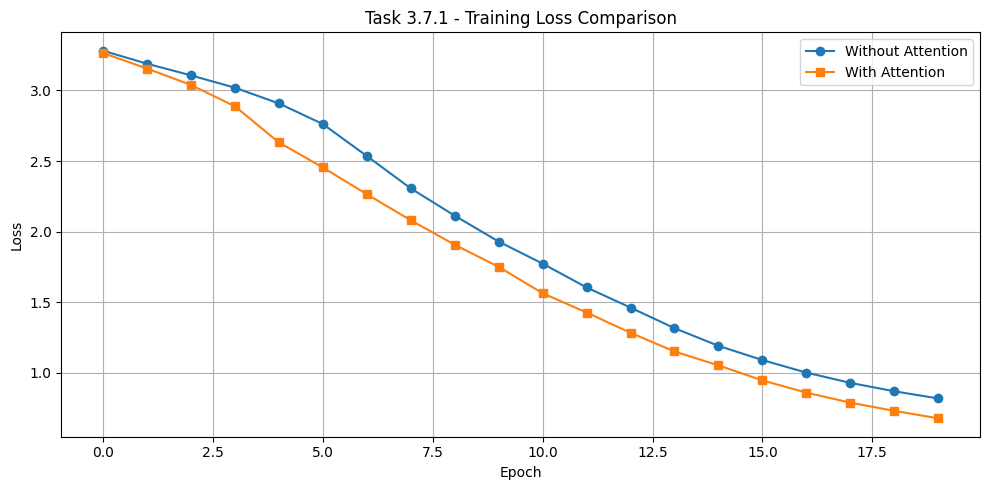


COMPARISON RESULTS
Model WITHOUT Attention:
  Final Loss: 0.8174
  Parameters: 205,979

Model WITH Attention:
  Final Loss: 0.6766
  Parameters: 304,540

Conclusion: Attention helps capture dependencies better!


In [5]:
def train_model(model, dataloader, epochs=10, lr=0.001, teacher_forcing_ratio=1.0):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)

            optimizer.zero_grad()
            outputs = model(src, tgt, teacher_forcing_ratio)

            loss = criterion(outputs.reshape(-1, outputs.size(-1)), tgt[:, 1:].reshape(-1))
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:2}/{epochs} | Loss: {avg_loss:.4f}")

    return losses

print("Training model WITHOUT attention...")
losses_no_att = train_model(model_no_att, dataloader, epochs=20)

print("\nTraining model WITH attention...")
losses_with_att = train_model(model_with_att, dataloader, epochs=20)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(losses_no_att, label='Without Attention', marker='o')
plt.plot(losses_with_att, label='With Attention', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Task 3.7.1 - Training Loss Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("COMPARISON RESULTS")
print("="*60)
print(f"Model WITHOUT Attention:")
print(f"  Final Loss: {losses_no_att[-1]:.4f}")
print(f"  Parameters: {sum(p.numel() for p in model_no_att.parameters()):,}")
print(f"\nModel WITH Attention:")
print(f"  Final Loss: {losses_with_att[-1]:.4f}")
print(f"  Parameters: {sum(p.numel() for p in model_with_att.parameters()):,}")
print(f"\nConclusion: Attention helps capture dependencies better!")

---
# Task 3.7.2 — Teacher-Forcing and Scheduled Sampling


Training with Teacher-Forcing Ratio: 0.0
Epoch  5/50 | Loss: 2.6881
Epoch 10/50 | Loss: 2.1931
Epoch 15/50 | Loss: 1.7740
Epoch 20/50 | Loss: 1.2292
Epoch 25/50 | Loss: 0.7080
Epoch 30/50 | Loss: 0.3813
Epoch 35/50 | Loss: 0.2174
Epoch 40/50 | Loss: 0.1398
Epoch 45/50 | Loss: 0.0987
Epoch 50/50 | Loss: 0.0753

Training with Teacher-Forcing Ratio: 0.5
Epoch  5/50 | Loss: 2.8345
Epoch 10/50 | Loss: 2.1689
Epoch 15/50 | Loss: 1.7904
Epoch 20/50 | Loss: 1.3371
Epoch 25/50 | Loss: 0.8549
Epoch 30/50 | Loss: 0.4400
Epoch 35/50 | Loss: 0.2476
Epoch 40/50 | Loss: 0.1533
Epoch 45/50 | Loss: 0.1057
Epoch 50/50 | Loss: 0.0794

Training with Teacher-Forcing Ratio: 1.0
Epoch  5/50 | Loss: 2.7285
Epoch 10/50 | Loss: 1.8292
Epoch 15/50 | Loss: 1.1110
Epoch 20/50 | Loss: 0.7025
Epoch 25/50 | Loss: 0.4591
Epoch 30/50 | Loss: 0.2695
Epoch 35/50 | Loss: 0.1496
Epoch 40/50 | Loss: 0.0924
Epoch 45/50 | Loss: 0.0646
Epoch 50/50 | Loss: 0.0488


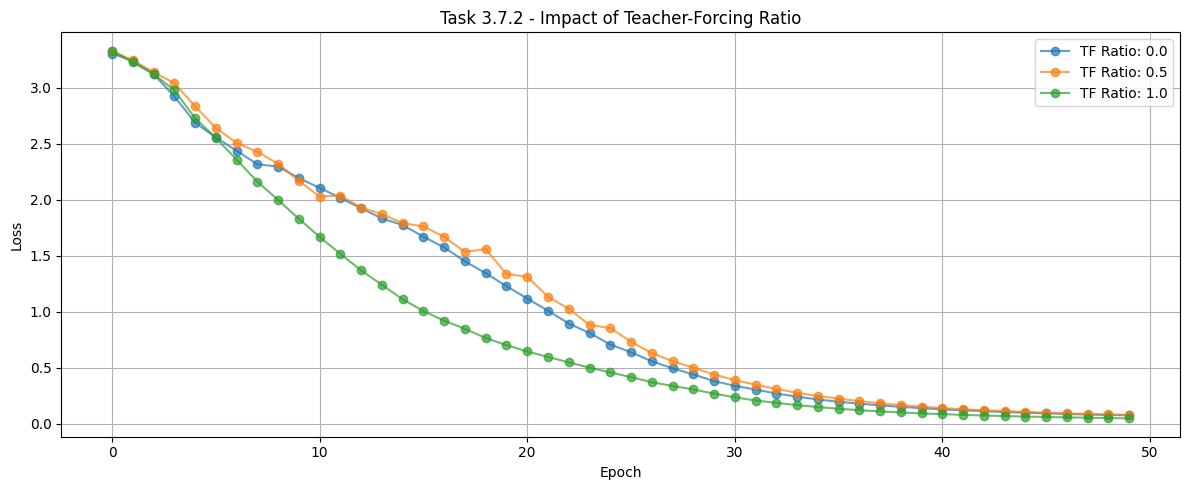


TEACHER-FORCING ANALYSIS

Teacher-Forcing Ratio 0.0:
  Final Loss: 0.0753
  Min Loss: 0.0753
  Convergence Speed: Reached min at epoch 50

Teacher-Forcing Ratio 0.5:
  Final Loss: 0.0794
  Min Loss: 0.0794
  Convergence Speed: Reached min at epoch 50

Teacher-Forcing Ratio 1.0:
  Final Loss: 0.0488
  Min Loss: 0.0488
  Convergence Speed: Reached min at epoch 50

Conclusion:
- 100% TF: Converges fastest but might cause exposure bias at inference
- 0% TF: More realistic but slower convergence
- 50% TF: Good balance between convergence and robustness


In [6]:
# Train with different teacher-forcing ratios
teacher_forcing_ratios = [0.0, 0.5, 1.0]
results = {}

for ratio in teacher_forcing_ratios:
    print(f"\nTraining with Teacher-Forcing Ratio: {ratio}")
    model = Seq2SeqWithAttention(len(fr_vocab), len(en_vocab), 64, 128).to(device)
    losses = train_model(model, dataloader, epochs=50, teacher_forcing_ratio=ratio)
    results[ratio] = losses

# Plot comparison
plt.figure(figsize=(12, 5))
for ratio in teacher_forcing_ratios:
    plt.plot(results[ratio], label=f'TF Ratio: {ratio}', marker='o', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Task 3.7.2 - Impact of Teacher-Forcing Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TEACHER-FORCING ANALYSIS")
print("="*60)
for ratio in teacher_forcing_ratios:
    final_loss = results[ratio][-1]
    min_loss = min(results[ratio])
    print(f"\nTeacher-Forcing Ratio {ratio}:")
    print(f"  Final Loss: {final_loss:.4f}")
    print(f"  Min Loss: {min_loss:.4f}")
    print(f"  Convergence Speed: Reached min at epoch {results[ratio].index(min_loss)+1}")

print("\nConclusion:")
print("- 100% TF: Converges fastest but might cause exposure bias at inference")
print("- 0% TF: More realistic but slower convergence")
print("- 50% TF: Good balance between convergence and robustness")

---
# Task 3.7.3 — Dot-Product (Luong) Attention

## Luong Attention Mechanism

In [7]:
class LuongAttention(nn.Module):
    """
    Luong (multiplicative) attention: score = h_t^T * W * h_s
    Where h_t is decoder hidden, h_s is encoder hidden
    This is simpler than Bahdanau (additive) attention
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: [batch, hidden_dim]
        # encoder_outputs: [batch, seq_len, hidden_dim]

        # Transform decoder hidden: [batch, hidden_dim]
        transformed = self.W(decoder_hidden)  # [batch, hidden_dim]

        # Dot product with encoder outputs
        # [batch, 1, hidden_dim] x [batch, hidden_dim, seq_len] -> [batch, 1, seq_len]
        attn_scores = torch.bmm(
            transformed.unsqueeze(1),
            encoder_outputs.transpose(1, 2)
        ).squeeze(1)  # [batch, seq_len]

        # Softmax
        attn_weights = torch.softmax(attn_scores, dim=1)  # [batch, seq_len]

        # Context vector: weighted sum of encoder outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # [batch, 1, hidden_dim]
        return context.squeeze(1), attn_weights

class DecoderLuongAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.attention = LuongAttention(hidden_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.concat = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h, c, encoder_outputs):
        embedded = self.embedding(x)  # [batch, 1, emb_dim]
        out, (h, c) = self.lstm(embedded, (h, c))  # [batch, 1, hidden_dim]

        context, attn_weights = self.attention(h.squeeze(0), encoder_outputs)

        # Concatenate output and context
        combined = torch.cat([out.squeeze(1), context], dim=1)
        attentional_output = torch.tanh(self.concat(combined))

        logits = self.fc(attentional_output)
        return logits, h, c, attn_weights

class Seq2SeqLuongAttention(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, embedding_dim, hidden_dim)
        self.decoder = DecoderLuongAttention(tgt_vocab_size, embedding_dim, hidden_dim)

    def forward(self, src, tgt, teacher_forcing_ratio=1.0):
        batch_size, seq_len = tgt.shape
        outputs = []

        h, c = self.encoder(src)

        embedded_src = self.encoder.embedding(src)
        encoder_outputs, _ = self.encoder.lstm(embedded_src)

        decoder_input = tgt[:, 0].unsqueeze(1)

        for t in range(1, seq_len):
            logits, h, c, _ = self.decoder(decoder_input, h, c, encoder_outputs)
            outputs.append(logits.unsqueeze(1))

            if random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t].unsqueeze(1)
            else:
                decoder_input = logits.argmax(1).unsqueeze(1)

        outputs = torch.cat(outputs, dim=1)
        return outputs

print("Luong Attention model created!")

# Train and compare
print("\nTraining Luong Attention model...")
model_luong = Seq2SeqLuongAttention(len(fr_vocab), len(en_vocab), 64, 128).to(device)
losses_luong = train_model(model_luong, dataloader, epochs=50)

print("\n" + "="*60)
print("ATTENTION MECHANISM COMPARISON")
print("="*60)
print(f"Bahdanau (Additive) Attention:")
print(f"  Final Loss: {losses_with_att[-1]:.4f}")
print(f"  Mechanism: score = v^T * tanh(W * [h_t; h_s])")
print(f"\nLuong (Multiplicative) Attention:")
print(f"  Final Loss: {losses_luong[-1]:.4f}")
print(f"  Mechanism: score = h_t^T * W * h_s")
print(f"\nLuong is simpler and often faster!")

Luong Attention model created!

Training Luong Attention model...
Epoch  5/50 | Loss: 2.7230
Epoch 10/50 | Loss: 1.5405
Epoch 15/50 | Loss: 0.6809
Epoch 20/50 | Loss: 0.2777
Epoch 25/50 | Loss: 0.1278
Epoch 30/50 | Loss: 0.0749
Epoch 35/50 | Loss: 0.0514
Epoch 40/50 | Loss: 0.0384
Epoch 45/50 | Loss: 0.0301
Epoch 50/50 | Loss: 0.0246

ATTENTION MECHANISM COMPARISON
Bahdanau (Additive) Attention:
  Final Loss: 0.6766
  Mechanism: score = v^T * tanh(W * [h_t; h_s])

Luong (Multiplicative) Attention:
  Final Loss: 0.0246
  Mechanism: score = h_t^T * W * h_s

Luong is simpler and often faster!


---
# Task 3.7.4 — AutoEncoder for Text

## Seq2Seq AutoEncoder (Input = Output)

In [19]:
# For autoencoder, same sentences for both input and output
autoencoder_dataset = TranslationDataset(french_sentences, french_sentences, fr_vocab, fr_vocab)
autoencoder_dataloader = DataLoader(autoencoder_dataset, batch_size=2, shuffle=True)

model_seq2seq_ae = Seq2SeqWithAttention(len(fr_vocab), len(fr_vocab), 64, 128).to(device)

print("Training Seq2Seq AutoEncoder...")
losses_seq2seq_ae = train_model(model_seq2seq_ae, autoencoder_dataloader, epochs=30)

print(f"\nSeq2Seq AutoEncoder Final Loss: {losses_seq2seq_ae[-1]:.4f}")
print(f"Parameters: {sum(p.numel() for p in model_seq2seq_ae.parameters()):,}")

Training Seq2Seq AutoEncoder...
Epoch  5/30 | Loss: 2.9437
Epoch 10/30 | Loss: 1.9276
Epoch 15/30 | Loss: 1.0889
Epoch 20/30 | Loss: 0.6689
Epoch 25/30 | Loss: 0.4208
Epoch 30/30 | Loss: 0.2446

Seq2Seq AutoEncoder Final Loss: 0.2446
Parameters: 305,698


## Simple Feedforward AutoEncoder for Comparison

In [17]:
class FeedforwardAutoEncoder(nn.Module):
    def __init__(self, vocab_size, input_dim=20):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32, padding_idx=0)

        self.encoder = nn.Sequential(
            nn.Linear(32 * input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 32 * input_dim)
        )

        self.fc = nn.Linear(32, vocab_size)
        self.input_dim = input_dim
        self.vocab_size = vocab_size

    def forward(self, x, tgt=None, teacher_forcing_ratio=None):
        # x: [batch, seq_len]
        embedded = self.embedding(x)  # [batch, seq_len, 32]
        flattened = embedded.reshape(embedded.size(0), -1)  # [batch, seq_len*32]

        encoded = self.encoder(flattened)  # [batch, 64]
        decoded = self.decoder(encoded)     # [batch, seq_len*32]

        # Reshape back
        decoded = decoded.reshape(-1, self.input_dim, 32)  # [batch, seq_len, 32]

        # Project to vocab size - skip first timestep to match Seq2Seq
        logits = self.fc(decoded[:, 1:, :])  # [batch, seq_len-1, vocab_size]

        return logits

model_ff_ae = FeedforwardAutoEncoder(len(fr_vocab)).to(device)

print("Training Feedforward AutoEncoder...")
losses_ff_ae = train_model(model_ff_ae, autoencoder_dataloader, epochs=30)

print(f"\nFeedforward AutoEncoder Final Loss: {losses_ff_ae[-1]:.4f}")
print(f"Parameters: {sum(p.numel() for p in model_ff_ae.parameters()):,}")

Training Feedforward AutoEncoder...
Epoch  5/30 | Loss: 3.0289
Epoch 10/30 | Loss: 1.3518
Epoch 15/30 | Loss: 0.4030
Epoch 20/30 | Loss: 0.0739
Epoch 25/30 | Loss: 0.0161
Epoch 30/30 | Loss: 0.0068

Feedforward AutoEncoder Final Loss: 0.0068
Parameters: 183,329


## Comparison and Analysis

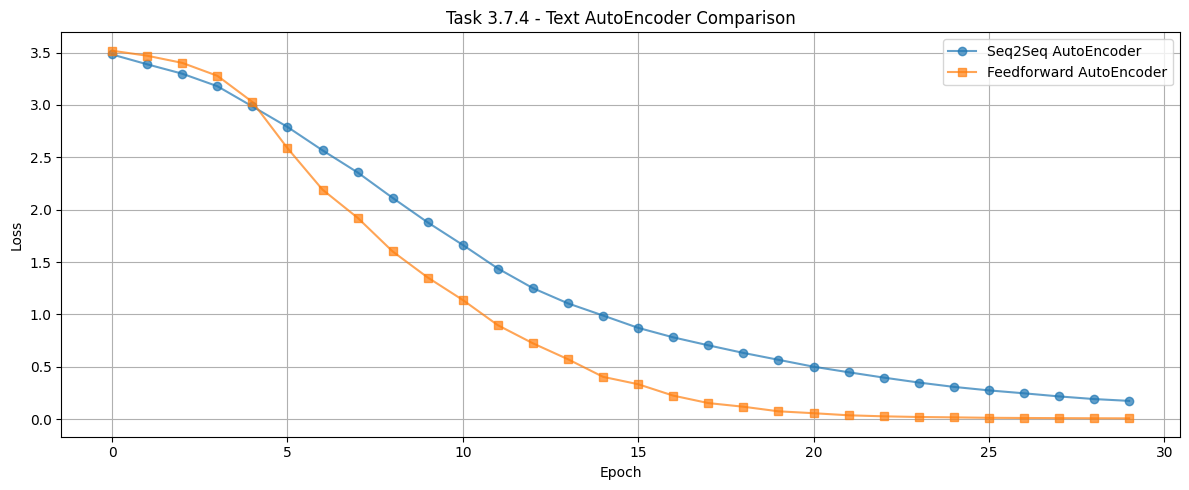

TEXT AUTOENCODER COMPARISON

1. MODEL SIZE:
   Seq2Seq:     305,698 parameters
   Feedforward: 183,329 parameters

2. FINAL LOSS:
   Seq2Seq:     0.1735
   Feedforward: 0.0068

3. ABILITY TO CAPTURE LONG-RANGE DEPENDENCIES:
   Seq2Seq:     EXCELLENT (LSTM processes sequentially, maintains context)
   Feedforward: LIMITED (treats sequence as flat vector, loses order)

4. TRAINING TIME:
   Seq2Seq:     Slower (recurrent computation, 50 steps per sequence)
   Feedforward: Faster (single forward pass per sequence)

5. ADVANTAGES & DISADVANTAGES:

   Seq2Seq AutoEncoder:
   + Captures long-range dependencies naturally
   + Better for variable-length sequences
   + More suitable for language/order matters
   - Slower training and inference
   - More parameters for small datasets

   Feedforward AutoEncoder:
   + Simpler architecture
   + Faster training and inference
   + Fewer parameters (good for small data)
   - Loses sequential order information
   - Treats all positions equally
   - Fix

In [18]:
# Plot comparison
plt.figure(figsize=(12, 5))
plt.plot(losses_seq2seq_ae, label='Seq2Seq AutoEncoder', marker='o', alpha=0.7)
plt.plot(losses_ff_ae, label='Feedforward AutoEncoder', marker='s', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Task 3.7.4 - Text AutoEncoder Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("="*70)
print("TEXT AUTOENCODER COMPARISON")
print("="*70)

seq2seq_params = sum(p.numel() for p in model_seq2seq_ae.parameters())
ff_params = sum(p.numel() for p in model_ff_ae.parameters())

print(f"\n1. MODEL SIZE:")
print(f"   Seq2Seq:     {seq2seq_params:,} parameters")
print(f"   Feedforward: {ff_params:,} parameters")

print(f"\n2. FINAL LOSS:")
print(f"   Seq2Seq:     {losses_seq2seq_ae[-1]:.4f}")
print(f"   Feedforward: {losses_ff_ae[-1]:.4f}")

print(f"\n3. ABILITY TO CAPTURE LONG-RANGE DEPENDENCIES:")
print(f"   Seq2Seq:     EXCELLENT (LSTM processes sequentially, maintains context)")
print(f"   Feedforward: LIMITED (treats sequence as flat vector, loses order)")

print(f"\n4. TRAINING TIME:")
print(f"   Seq2Seq:     Slower (recurrent computation, 50 steps per sequence)")
print(f"   Feedforward: Faster (single forward pass per sequence)")

print(f"\n5. ADVANTAGES & DISADVANTAGES:")
print(f"\n   Seq2Seq AutoEncoder:")
print(f"   + Captures long-range dependencies naturally")
print(f"   + Better for variable-length sequences")
print(f"   + More suitable for language/order matters")
print(f"   - Slower training and inference")
print(f"   - More parameters for small datasets")

print(f"\n   Feedforward AutoEncoder:")
print(f"   + Simpler architecture")
print(f"   + Faster training and inference")
print(f"   + Fewer parameters (good for small data)")
print(f"   - Loses sequential order information")
print(f"   - Treats all positions equally")
print(f"   - Fixed sequence length requirement")

print(f"\n6. WHEN TO USE EACH:")
print(f"   Seq2Seq:     Text reconstruction, machine translation, language tasks")
print(f"   Feedforward: Very simple patterns, fixed structure, speed critical")